In [1]:
import pandas as pd
import numpy as np
import itertools
import os
from Generation.Generator import *
from tsib.plot_building import plot_building
df = pd.read_csv(r"tsib\data\episcope\episcope.csv")

In [2]:
df = pd.read_csv(r"tsib\data\episcope\episcope.csv")

In [3]:
#building type
#n apartments
#occ
# flat area



# Manifest Generator

In [4]:
man = manifest(scenario_reps=120,
                    seed_reps=3,
                    episcope_path=r"tsib\data\episcope\episcope.csv",
                    building_types= ["SFH"], #, "MFH", "TH", "AB"
                    seed=42, overwrite=True)
print(man.shape)
print(man.head())
print(man.dtypes)

(4320, 24)
  country buildingType surrounding buildingAgeBin  a_ref  n_apartments  \
0      DE          SFH    Detached          DE.01   89.8             1   
1      DE          SFH    Detached          DE.01   89.8             1   
2      DE          SFH    Detached          DE.01   89.8             1   
3      DE          SFH    Detached          DE.01  149.9             1   
4      DE          SFH    Detached          DE.01  149.9             1   

  year_type  future  climateRegion n_persons  ... nightReduction  capControl  \
0      cold   False              4       [5]  ...           True        True   
1      cold   False              4       [5]  ...           True        True   
2      cold   False              4       [5]  ...           True        True   
3       hot    True             12       [2]  ...           True        True   
4       hot    True             12       [2]  ...           True        True   

   occControl  comfortT_lb  comfortT_ub  cores  useCache  build

In [5]:
man

,country,buildingType,surrounding,buildingAgeBin,a_ref,n_apartments,year_type,future,climateRegion,n_persons,...,nightReduction,capControl,occControl,comfortT_lb,comfortT_ub,cores,useCache,building_id,run_id,seed
0,DE,SFH,Detached,DE.01,89.8,1,cold,False,4,[5],...,True,True,False,21.0,24.0,1,False,0,run_000000,1000000
1,DE,SFH,Detached,DE.01,89.8,1,cold,False,4,[5],...,True,True,False,21.0,24.0,1,False,0,run_000001,1000001
2,DE,SFH,Detached,DE.01,89.8,1,cold,False,4,[5],...,True,True,False,21.0,24.0,1,False,0,run_000002,1000002
3,DE,SFH,Detached,DE.01,149.9,1,hot,True,12,[2],...,True,True,False,21.0,24.0,1,False,1,run_000003,1000003
4,DE,SFH,Detached,DE.01,149.9,1,hot,True,12,[2],...,True,True,False,21.0,24.0,1,False,1,run_000004,1000004
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4315,DE,SFH,Detached,DE.12,98.4,1,hot,True,14,[2],...,True,True,False,21.0,24.0,1,False,1438,run_004315,1004315
4316,DE,SFH,Detached,DE.12,98.4,1,hot,True,14,[2],...,True,True,False,21.0,24.0,1,False,1438,run_004316,1004316
4317,DE,SFH,Detached,DE.12,183.2,1,hot,True,4,[2],...,True,True,False,21.0,24.0,1,False,1439,run_004317,1004317
4318,DE,SFH,Detached,DE.12,183.2,1,hot,True,4,[2],...,True,True,False,21.0,24.0,1,False,1439,run_004318,1004318


# Generator

In [7]:
validate_manifest(man,3)

Manifest validation successful.
Runs:              4,320
Unique buildings:  1,440
Seed repetitions:  3

Buildings by type:
buildingType
SFH    1440
Name: count, dtype: int64

Climate regions:
climateRegion
1     96
2     96
3     96
4     96
5     96
6     96
7     96
8     96
9     96
10    96
11    96
12    96
13    96
14    96
15    96
Name: count, dtype: int64


In [17]:
manifest_run("Generation/manifest.parquet",res_dir="Generation/results", fail_log="failures.log", max_cores=10)

Total:4320, Remain: 4310, Done: 10


Running Simulations:   1%|          | 30/4310 [04:45<11:18:18,  9.51s/runs, done=30, failed=0]


KeyboardInterrupt: 

In [10]:
row = man.loc[5].to_dict()

In [11]:
row

{'country': 'DE',
 'buildingType': 'SFH',
 'surrounding': 'Detached',
 'buildingAgeBin': 'DE.01',
 'a_ref': 149.9,
 'n_apartments': 1,
 'year_type': 'hot',
 'future': True,
 'climateRegion': 12,
 'n_persons': [2],
 'freq': '1min',
 'hasFirePlace': False,
 'varyoccupancy': 1,
 'mean_load': False,
 'nightReduction': True,
 'capControl': True,
 'occControl': False,
 'comfortT_lb': 21.0,
 'comfortT_ub': 24.0,
 'cores': 1,
 'useCache': False,
 'building_id': 1,
 'run_id': 'run_000005',
 'seed': 1000005}

In [9]:
row["year_type"] = "test"

In [12]:
run_id = row["run_id"]
result_path = RESULTS_DIR / f"{run_id}.h5"

single_run(row)

ts1 = pd.read_hdf(result_path, "timeseries")
params1 = pd.read_hdf(result_path, "params")

result_path.unlink()

single_run(row)

ts2 = pd.read_hdf(result_path, "timeseries")
params2 = pd.read_hdf(result_path, "params")


Variables: 131413
Constraints: 271575
Variables: 131413
Constraints: 271575


In [13]:
ignore_cols = ["runtime_seconds"]

params1_cmp = params1.drop(columns=ignore_cols, errors="ignore")
params2_cmp = params2.drop(columns=ignore_cols, errors="ignore")

pd.testing.assert_frame_equal(ts1, ts2)
pd.testing.assert_frame_equal(params1_cmp, params2_cmp)

print("Determinism test passed.")

Determinism test passed.


In [11]:
import numpy as np
import pandas as pd
from tsib.buildingmodel import TOTAL_PROFILE_NUM  # use whatever value is actually configured right now

manifest = pd.read_parquet("Generation/manifest.parquet")

seen = {}
collisions = 0
total_draws = 0

for _, row in manifest.iterrows():
    seed = int(row["seed"])

    n_apartments = int(row["n_apartments"])
    n_persons = row["n_persons"]  # already a real list, thanks to parquet

    rng = np.random.default_rng(seed)
    draw = rng.choice(TOTAL_PROFILE_NUM, size=n_apartments, replace=False)
    print(draw)
    for idx, persons in zip(draw, n_persons):
        key = (int(persons), int(idx))  # matches tsib's actual cache key: (n_persons, seed-index)
        if key in seen:
            collisions += 1
        seen[key] = True
        total_draws += 1

pct = collisions / total_draws * 100 if total_draws else 0
print(f"TOTAL_PROFILE_NUM = {TOTAL_PROFILE_NUM}")
print(f"{collisions} collisions out of {total_draws} total household draws ({pct:.1f}%)")

[6767831]
[4647808]
[7338742]
[846743]
[3400979]
[6876757]
[8578783]
[9966062]
[9249308]
[6792101]
[8450569]
[5016519]
[8614716]
[6843187]
[4844919]
[8358361]
[4943760]
[2971441]
[3792076]
[9549404]
[7758434]
[5691143]
[7150930]
[6608140]
[671343]
[4778293]
[1129539]
[8874391]
[249639]
[6503452]
[5607634]
[2128662]
[6326737]
[5792059]
[9759125]
[9306379]
[1165137]
[918358]
[2893856]
[762144]
[1788367]
[3568063]
[1953800]
[5357277]
[9164239]
[4130219]
[4950409]
[156419]
[7273471]
[5204021]
[276772]
[4264078]
[3448898]
[4319383]
[5597858]
[9259727]
[5653860]
[1991634]
[1080254]
[4057336]
[5780683]
[8971004]
[8153199]
[5664617]
[5469454]
[1995439]
[3539913]
[2330295]
[4089652]
[4199930]
[6807853]
[1121869]
[7973990]
[8150815]
[9315811]
[9924804]
[8898216]
[5529210]
[9617959]
[8316436]
[5860464]
[8869371]
[1287920]
[9904406]
[4295363]
[6074442]
[6101032]
[8908198]
[4583057]
[1904749]
[4451778]
[7546258]
[7889457]
[4057991]
[1055135]
[9041761]
[9662553]
[7551196]
[8682824]
[7736461]
[262027

In [7]:
RESULTS_DIR

WindowsPath('C:/Users/Samuel/FH_Aachen/tsib_simuflex_fork/tsib_simuflex/Generation/results')

In [18]:
result_files = list(RESULTS_DIR.glob("run_*.h5"))
print("Result files:", len(result_files))

Result files: 40


In [25]:
sample = result_files[2]

with pd.HDFStore(sample, mode="r") as store:
    print(store)
    print(store.keys())

    ts = store["timeseries"]
    params = store["params"]

print(ts.head())
print(params.T)

<class 'pandas.HDFStore'>
File path: C:\Users\Samuel\FH_Aachen\tsib_simuflex_fork\tsib_simuflex\Generation\results\run_000002.h5

['/params', '/timeseries']
                             T  Occupancy Home Active  \
2010-01-01 00:00:00+01:00 -2.7                    0.0   
2010-01-01 00:01:00+01:00 -2.7                    0.0   
2010-01-01 00:02:00+01:00 -2.7                    0.0   
2010-01-01 00:03:00+01:00 -2.7                    0.0   
2010-01-01 00:04:00+01:00 -2.7                    0.0   

                           Occupancy Home Not Active  Electricity Load  \
2010-01-01 00:00:00+01:00                        4.0          0.065085   
2010-01-01 00:01:00+01:00                        4.0          0.065085   
2010-01-01 00:02:00+01:00                        4.0          0.065085   
2010-01-01 00:03:00+01:00                        4.0          0.065085   
2010-01-01 00:04:00+01:00                        4.0          0.065085   

                           Hot Water Load  Heating Load

In [22]:
params["n_persons"][0]

'[2]'

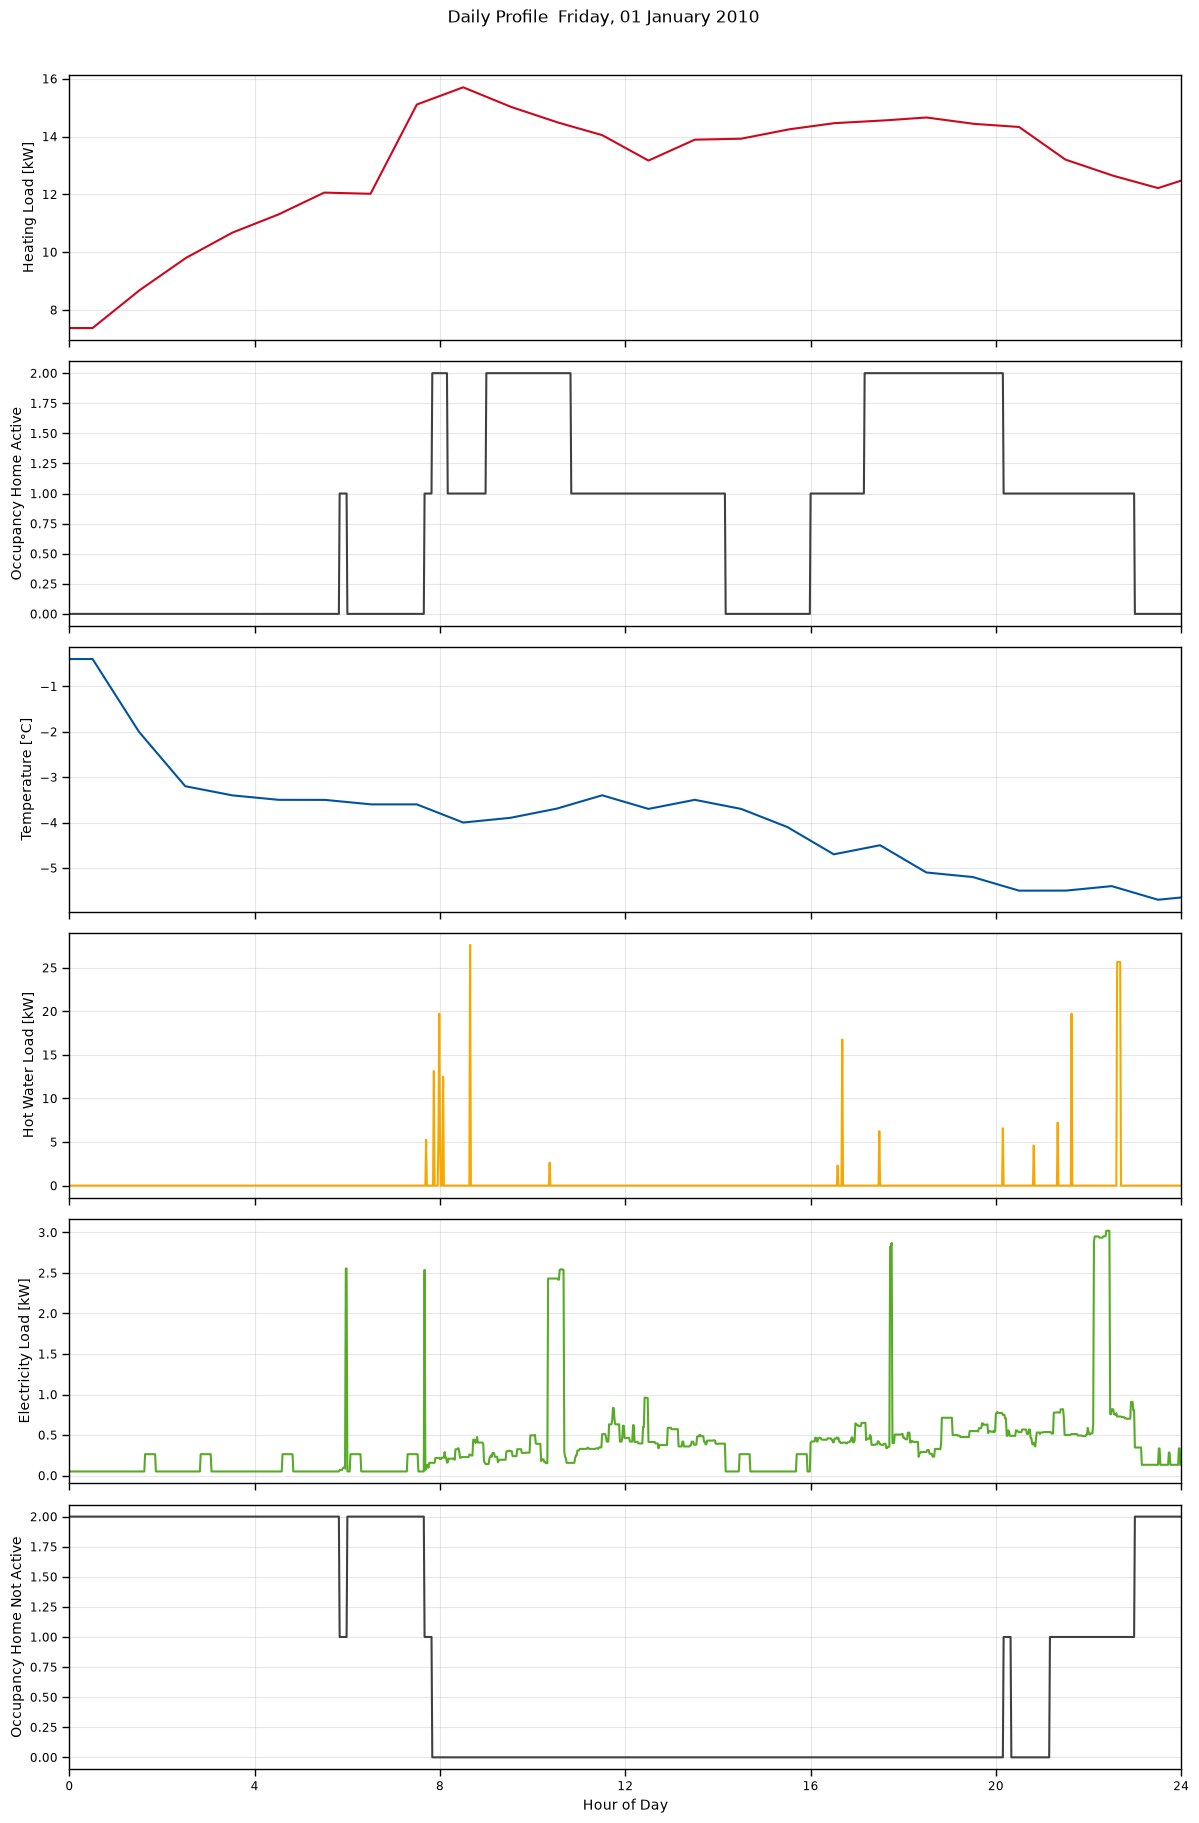

In [23]:
plot_building(ts, mode="day", day_of_year=1,profiles=["Heating Load","Occupancy Home Active","T" ,"Hot Water Load", "Electricity Load", "Occupancy Home Not Active"])

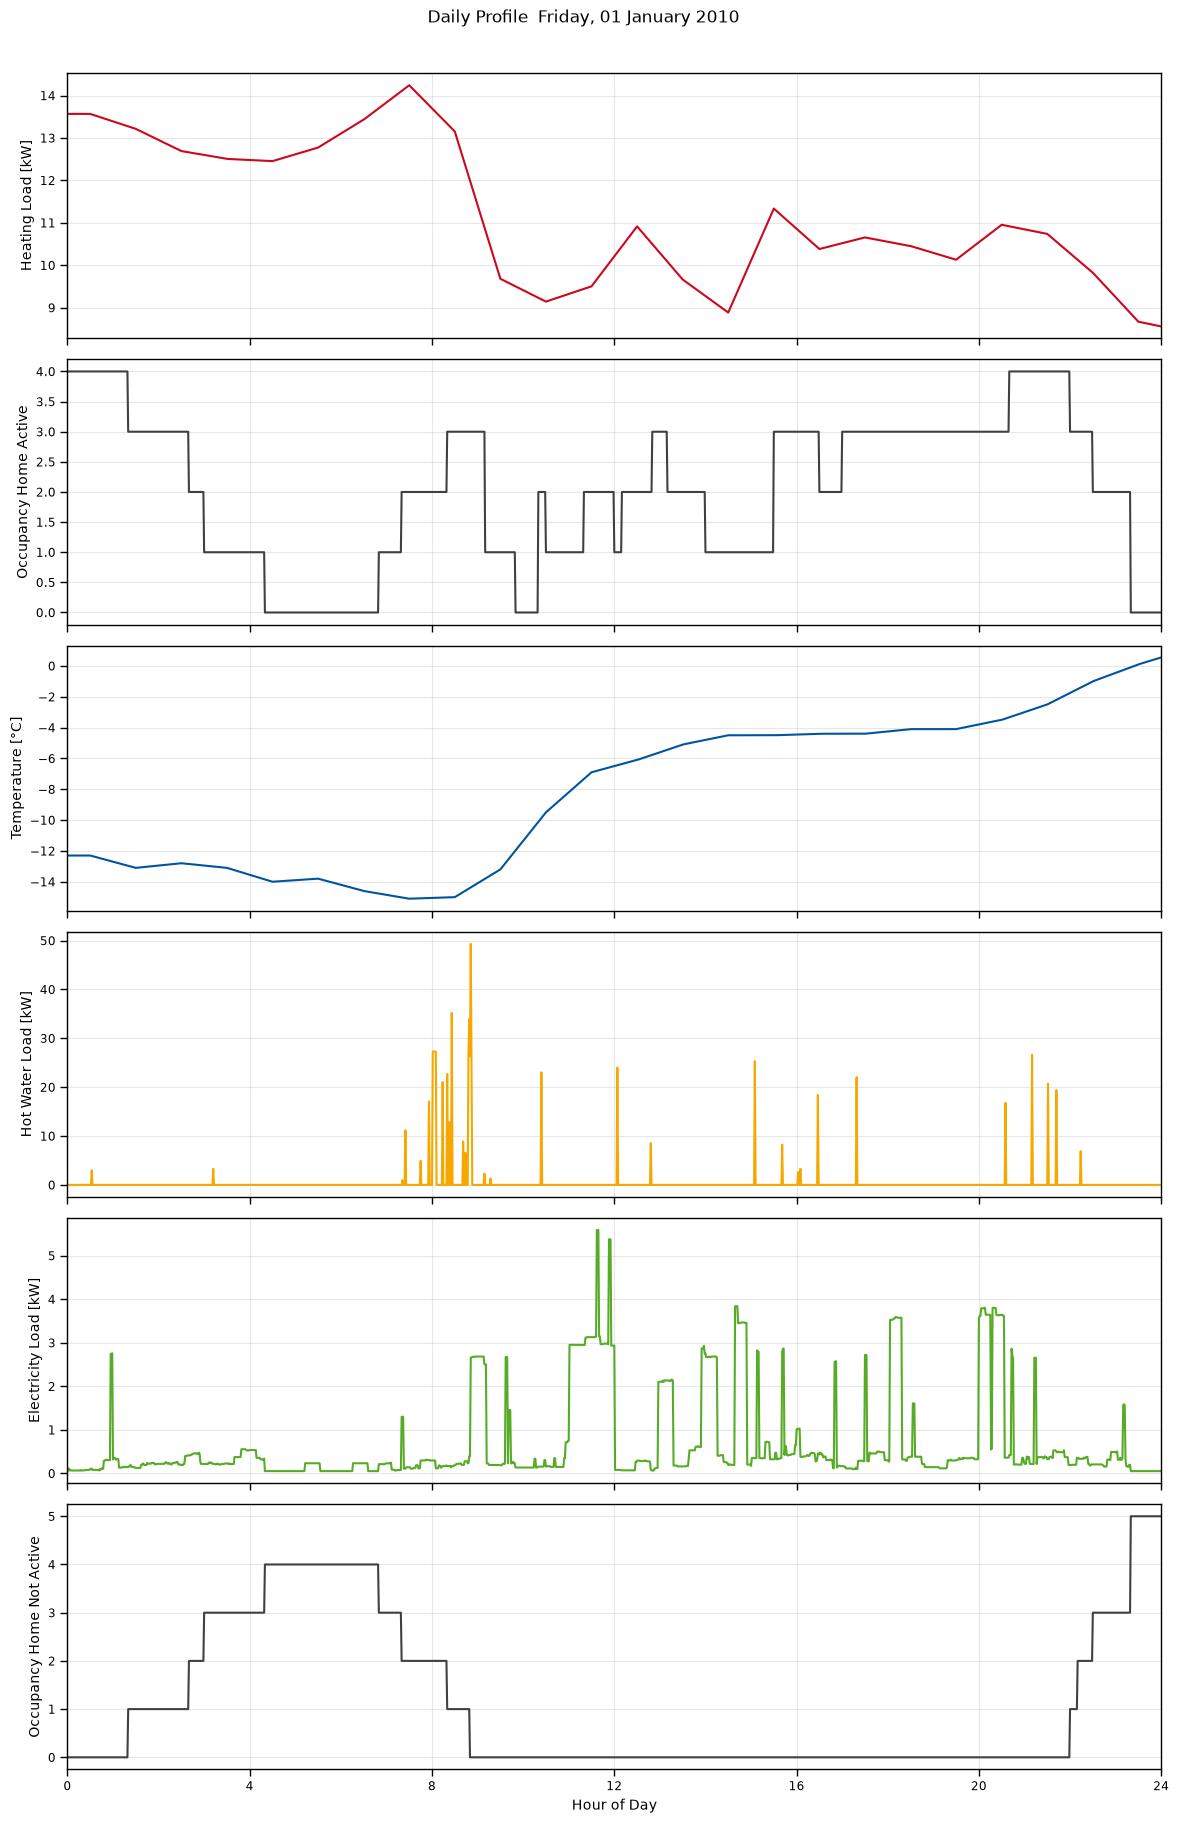

In [20]:
plot_building(ts, mode="day", day_of_year=1,profiles=["Heating Load","Occupancy Home Active","T" ,"Hot Water Load", "Electricity Load", "Occupancy Home Not Active"])

In [15]:
ts

,T,Occupancy Home Active,Occupancy Home Not Active,Electricity Load,Hot Water Load,Heating Load
2010-01-01 00:00:00+01:00,-12.3,4.0,0.0,0.052525,0.0,13.849985
2010-01-01 00:01:00+01:00,-12.3,4.0,0.0,0.066227,0.0,13.849985
2010-01-01 00:02:00+01:00,-12.3,4.0,0.0,0.114184,0.0,13.849985
2010-01-01 00:03:00+01:00,-12.3,4.0,0.0,0.066227,0.0,13.849985
2010-01-01 00:04:00+01:00,-12.3,4.0,0.0,0.079929,0.0,13.849985
...,...,...,...,...,...,...
2010-12-31 23:55:00+01:00,-11.2,0.0,5.0,0.052313,0.0,11.219488
2010-12-31 23:56:00+01:00,-11.2,0.0,5.0,0.052313,0.0,11.219488
2010-12-31 23:57:00+01:00,-11.2,0.0,5.0,0.052313,0.0,11.219488
2010-12-31 23:58:00+01:00,-11.2,0.0,5.0,0.052313,0.0,11.219488


In [16]:
params

,country,buildingType,surrounding,buildingAgeBin,a_ref,n_apartments,year_type,future,climateRegion,n_persons,...,seed,weatherFilepath,weatherID,resolved_climateRegion,resolved_latitude,resolved_longitude,state_seed,apartment_seeds,maxLoadViolation_kW,runtime_seconds
0,DE,SFH,Detached,DE.01,89.8,1,cold,False,4,[5],...,1000000,C:\Users\Samuel\FH_Aachen\tsib_simuflex_fork\t...,TRY2015_4_cold_TRY2015_517601142841_Wint,4,51.7601,14.2841,1000000,[1341242],1.269682e-11,75.496234


In [14]:
import pandas as pd

path = r"C:\Users\Samuel\FH_Aachen\tsib_simuflex_fork\tsib_simuflex\Generation\results\run_000047.h5"

# see what's actually stored inside, in case you forget the exact keys
with pd.HDFStore(path, mode="r") as store:
    print(store.keys())   # -> ['/timeseries', '/params']

timeseries = pd.read_hdf(path, key="timeseries")
params = pd.read_hdf(path, key="params")

print(params.T)          # transpose — easier to read a one-row table this way
print(timeseries.head())
print(timeseries.dtypes)

['/params', '/timeseries']
                                                                        0
country                                                                DE
buildingType                                                          SFH
surrounding                                                      Detached
buildingAgeBin                                                      DE.12
a_ref                                                               115.8
n_apartments                                                            1
year_type                                                         average
future                                                              False
climateRegion                                                           4
n_persons                                                             [3]
freq                                                                 1min
hasFirePlace                                                        False
cores      

In [32]:
store = pd.HDFStore(r"C:\Users\Samuel\Downloads\Ziel\test.h5", mode="w")

In [ ]:
os.replace()

In [38]:
store.put("manifest", df, format="table")

In [39]:
store.close()

In [41]:
store.open()

In [42]:
store.select("manifest")

,Unnamed: 0,Code_BuildingVariant,Date_Entry,Code_StatusDataset,Code_Country,Code_Building,Description_BuildingVariant,Description_BuildingVariant_National,Code_BuildingType,Code_DataType_Building,...,Q_Sol_South,Q_Sol_West,Q_Sol_North,q_sol,q_int,tau,a_H,gamma_h_gn,eta_h_gn,q_h_nd
0,11,AT.N.AB.01.Gen.ReEx.001.001,2015-09-04 00:00:00,Typology,AT,AT.N.AB.01.Gen.ReEx.001,Existing condition,Zustand Bestand,AT.N.AB.01.Gen,ReEx,...,0.000000,6113.728530,0.000000,8.975227,15.264,16.882835,1.362761,0.121795,0.949819,175.994029
1,14,AT.N.AB.02.Gen.ReEx.001.001,2010-09-07 00:00:00,Typology,AT,AT.N.AB.02.Gen.ReEx.001,Existing condition,Zustand Bestand,AT.N.AB.02.Gen,ReEx,...,111.334041,4263.592788,41.090868,8.083775,15.264,13.099762,1.236659,0.093664,0.951285,227.060285
2,17,AT.N.AB.03.Gen.ReEx.001.001,2010-09-07 00:00:00,Typology,AT,AT.N.AB.03.Gen.ReEx.001,Existing condition,Zustand Bestand,AT.N.AB.03.Gen,ReEx,...,5296.741632,355.400136,2335.270392,9.980548,15.264,15.986860,1.332895,0.120774,0.947081,185.113920
3,20,AT.N.AB.04.Gen.ReEx.001.001,2010-09-07 00:00:00,Typology,AT,AT.N.AB.04.Gen.ReEx.001,Existing condition,Zustand Bestand,AT.N.AB.04.Gen,ReEx,...,11725.543557,265.341258,2134.543320,15.381327,15.264,15.670092,1.322336,0.144009,0.933254,184.201843
4,23,AT.N.AB.05.Gen.ReEx.001.001,2010-09-07 00:00:00,Typology,AT,AT.N.AB.05.Gen.ReEx.001,Existing condition,Zustand Bestand,AT.N.AB.05.Gen,ReEx,...,5842.574010,469.031472,3886.177932,7.645423,15.264,45.440649,2.314688,0.281850,0.961117,59.263580
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
831,2979,SI.N.MFH-AB.03-04.Gen.SyAv.001.001,2015-07-03 00:00:00,Analysis,SI,SI.N.MFH-AB.03-04.Gen.SyAv.001,0,0,SI.N.MFH-AB.03-04.Gen,SyAv,...,9069.457950,6771.033675,3043.859175,8.547734,14.832,23.406668,1.580222,0.167339,0.950122,117.501205
832,2980,SI.N.MFH-AB.05-06.Gen.SyAv.001.001,2015-07-03 00:00:00,Analysis,SI,SI.N.MFH-AB.05-06.Gen.SyAv.001,0,0,SI.N.MFH-AB.05-06.Gen,SyAv,...,14004.334417,10455.290764,4700.084839,6.697053,14.832,52.073181,2.535773,0.320371,0.961403,46.502309
833,2981,SI.N.SFH-TH.01-02.Gen.SyAv.001.001,2015-07-03 00:00:00,Analysis,SI,SI.N.SFH-TH.01-02.Gen.SyAv.001,0,0,SI.N.SFH-TH.01-02.Gen,SyAv,...,649.838700,485.153550,218.096550,12.847136,14.832,12.861238,1.228708,0.122245,0.933030,200.597076
834,2982,SI.N.SFH-TH.03-04.Gen.SyAv.001.001,2015-07-03 00:00:00,Analysis,SI,SI.N.SFH-TH.03-04.Gen.SyAv.001,0,0,SI.N.SFH-TH.03-04.Gen,SyAv,...,411.943927,307.547179,138.255154,7.930485,14.832,22.540807,1.551360,0.166208,0.947942,115.374672


Rows: 14,400
Unique buildings: 4,800
Unique runs: 14,400

DATA TYPES
country            object
buildingType       object
surrounding        object
buildingAgeBin     object
a_ref             float64
n_apartments        int64
year_type          object
future               bool
climateRegion       int64
n_persons          object
freq               object
hasFirePlace         bool
varyoccupancy       int64
mean_load            bool
nightReduction       bool
capControl           bool
occControl           bool
comfortT_lb       float64
comfortT_ub       float64
cores               int64
useCache             bool
building_id         int64
run_id             object
seed                int64
dtype: object

MISSING VALUES
country           0
buildingType      0
surrounding       0
buildingAgeBin    0
a_ref             0
n_apartments      0
year_type         0
future            0
climateRegion     0
n_persons         0
freq              0
hasFirePlace      0
varyoccupancy     0
mean_load        

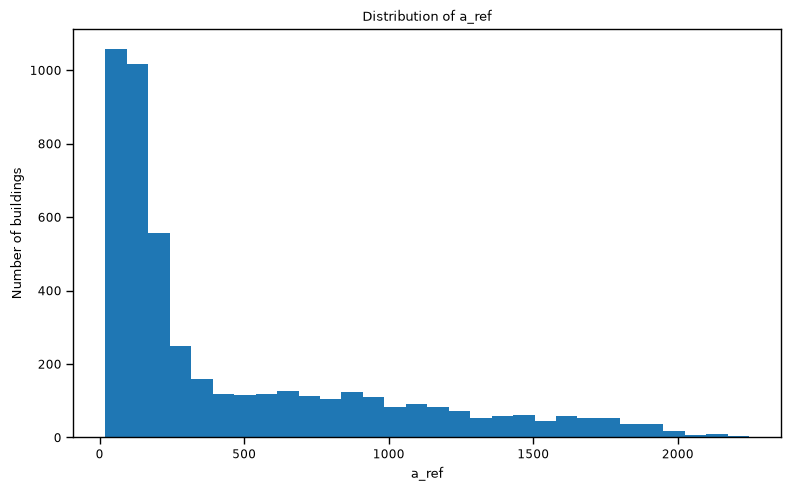

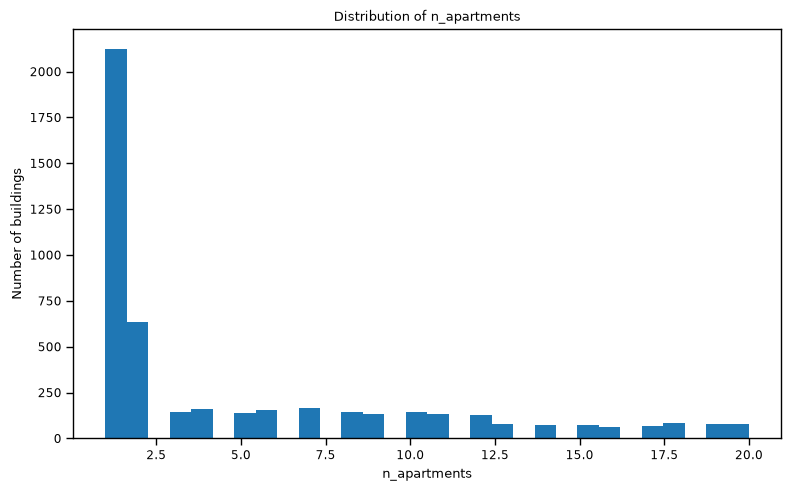

REFERENCE AREA BY BUILDING TYPE
               count         mean         std    min       25%      50%  \
buildingType                                                              
AB             600.0  1541.548000  273.922051  938.8  1332.625  1540.55   
MFH           1440.0   680.850625  284.217224  136.2   440.700   662.90   
SFH           1440.0   101.964375   43.094727   20.5    68.575    94.55   
TH            1320.0   155.163106   76.042794   20.1    92.975   146.00   

                   75%     max  
buildingType                    
AB            1745.175  2246.1  
MFH            899.875  1490.6  
SFH            131.625   199.9  
TH             207.175   391.1  



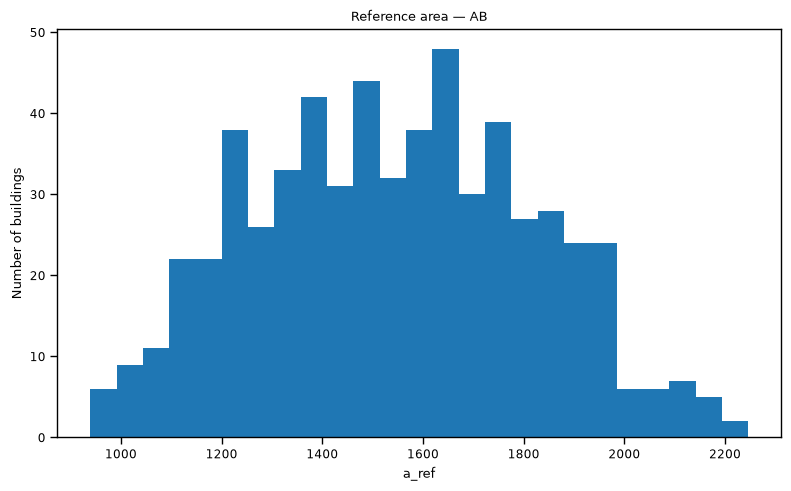

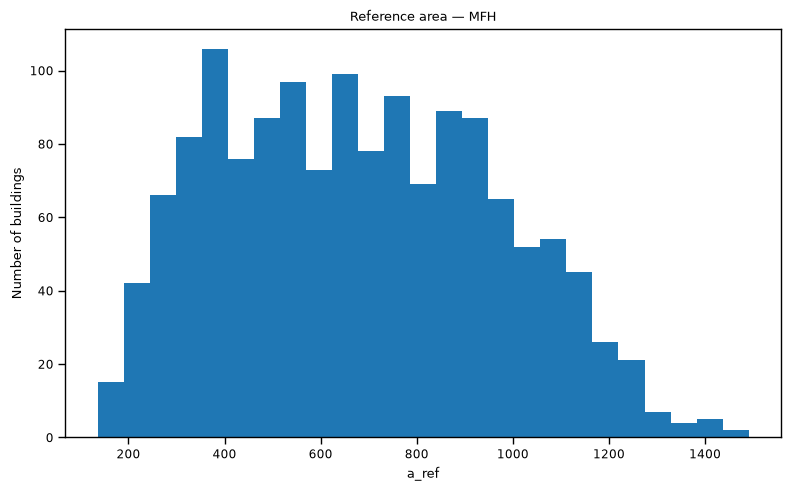

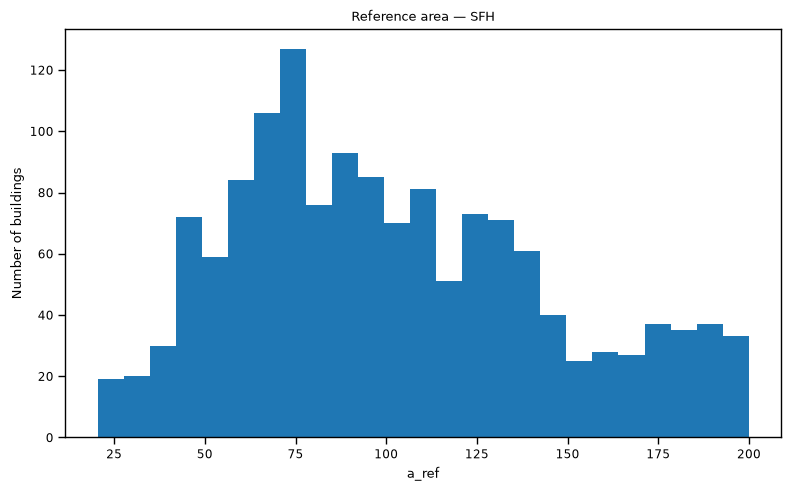

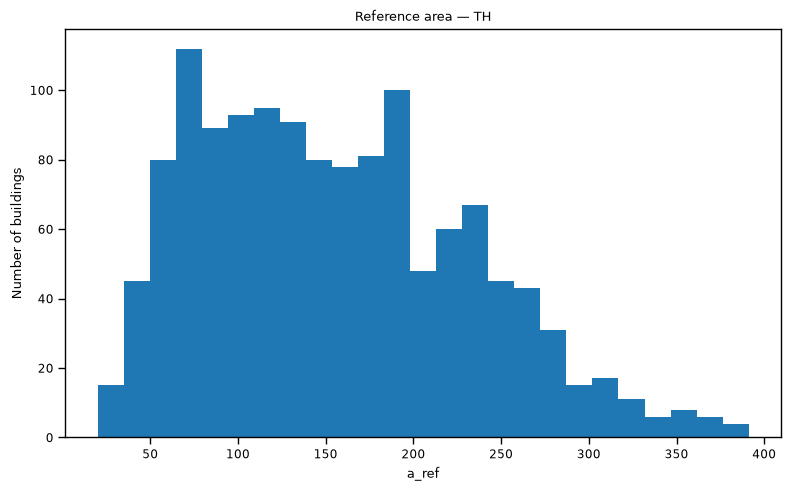

APARTMENT COUNT BY BUILDING TYPE
               count       mean       std   min   25%   50%   75%   max
buildingType                                                           
AB             600.0  16.568333  2.344032  13.0  14.0  17.0  19.0  20.0
MFH           1440.0   7.359722  2.839176   3.0   5.0   7.0  10.0  12.0
SFH           1440.0   1.000000  0.000000   1.0   1.0   1.0   1.0   1.0
TH            1320.0   1.481061  0.499831   1.0   1.0   1.0   2.0   2.0

CLIMATE REGION × BUILDING TYPE
climateRegion  1   2   3   4   5   6   7   8   9   10  11  12  13  14  15
buildingType                                                             
AB             40  40  40  40  40  40  40  40  40  40  40  40  40  40  40
MFH            96  96  96  96  96  96  96  96  96  96  96  96  96  96  96
SFH            96  96  96  96  96  96  96  96  96  96  96  96  96  96  96
TH             88  88  88  88  88  88  88  88  88  88  88  88  88  88  88

WEATHER SCENARIO × BUILDING TYPE
future         False     

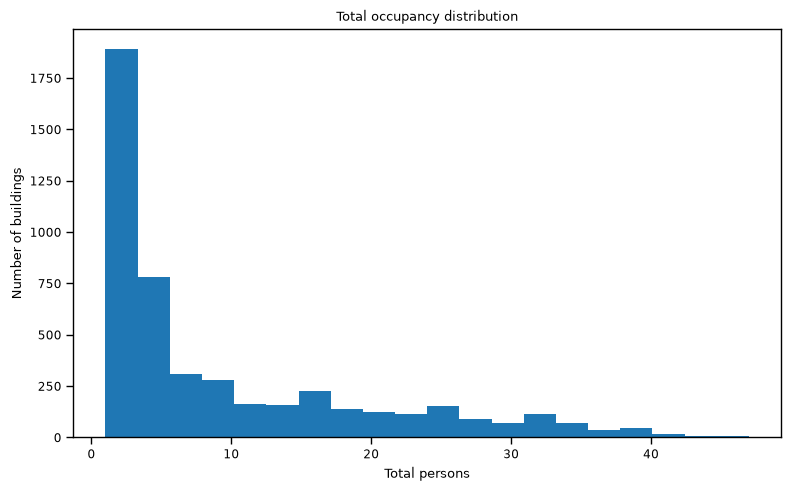


AREA PER PERSON
count    4800.000000
mean       50.452115
std        19.596998
min        10.050000
25%        38.825987
50%        48.080476
75%        58.183333
max       192.600000
Name: area_per_person, dtype: float64


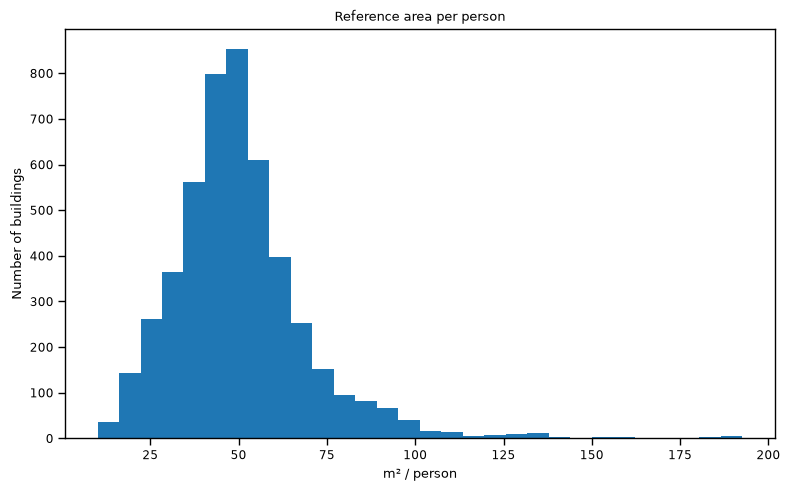

In [5]:
import pandas as pd
import matplotlib.pyplot as plt

MANIFEST_PATH = "Generation/manifest.parquet"

# --------------------------------------------------
# Load manifest
# --------------------------------------------------
df = pd.read_parquet(MANIFEST_PATH)

print(f"Rows: {len(df):,}")
print(f"Unique buildings: {df['building_id'].nunique():,}")
print(f"Unique runs: {df['run_id'].nunique():,}")
print()


# --------------------------------------------------
# 1. Basic overview
# --------------------------------------------------
print("=" * 80)
print("DATA TYPES")
print("=" * 80)
print(df.dtypes)
print()


print("=" * 80)
print("MISSING VALUES")
print("=" * 80)
print(df.isna().sum().sort_values(ascending=False))
print()


# --------------------------------------------------
# 2. Numeric parameter statistics
# --------------------------------------------------
numeric_cols = [
    "a_ref",
    "n_apartments",
    "climateRegion",
]

numeric_cols = [c for c in numeric_cols if c in df.columns]

print("=" * 80)
print("NUMERIC PARAMETER SUMMARY")
print("=" * 80)
print(df[numeric_cols].describe().T)
print()


# --------------------------------------------------
# 3. Categorical distributions
# --------------------------------------------------
categorical_cols = [
    "buildingType",
    "surrounding",
    "buildingAgeBin",
    "year_type",
    "future",
    "climateRegion",
]

for col in categorical_cols:
    if col not in df.columns:
        continue

    print("=" * 80)
    print(f"DISTRIBUTION: {col}")
    print("=" * 80)

    counts = df[col].value_counts(dropna=False).sort_index()
    percentages = df[col].value_counts(
        normalize=True,
        dropna=False
    ).sort_index() * 100

    distribution = pd.DataFrame({
        "count": counts,
        "percent": percentages
    })

    print(distribution)
    print()


# --------------------------------------------------
# 4. IMPORTANT:
# Avoid counting seed repetitions as distinct buildings
# --------------------------------------------------
building_df = (
    df
    .drop_duplicates("building_id")
    .copy()
)

print("=" * 80)
print("BUILDING-LEVEL DATA")
print("=" * 80)
print(f"Simulation rows: {len(df):,}")
print(f"Distinct building scenarios: {len(building_df):,}")
print()


# --------------------------------------------------
# 5. Building-level distributions
# --------------------------------------------------
for col in categorical_cols:
    if col not in building_df.columns:
        continue

    print("=" * 80)
    print(f"BUILDING-LEVEL DISTRIBUTION: {col}")
    print("=" * 80)

    counts = building_df[col].value_counts(dropna=False).sort_index()
    percentages = building_df[col].value_counts(
        normalize=True,
        dropna=False
    ).sort_index() * 100

    print(pd.DataFrame({
        "count": counts,
        "percent": percentages
    }))
    print()


# --------------------------------------------------
# 6. Histograms of important numeric building params
# --------------------------------------------------
hist_cols = [
    "a_ref",
    "n_apartments",
]

for col in hist_cols:
    if col not in building_df.columns:
        continue

    plt.figure(figsize=(8, 5))
    plt.hist(building_df[col].dropna(), bins=30)
    plt.xlabel(col)
    plt.ylabel("Number of buildings")
    plt.title(f"Distribution of {col}")
    plt.tight_layout()
    plt.show()


# --------------------------------------------------
# 7. Reference area by building type
# --------------------------------------------------
if {"buildingType", "a_ref"}.issubset(building_df.columns):

    print("=" * 80)
    print("REFERENCE AREA BY BUILDING TYPE")
    print("=" * 80)

    print(
        building_df
        .groupby("buildingType")["a_ref"]
        .describe()
    )
    print()

    building_types = building_df["buildingType"].dropna().unique()

    for building_type in sorted(building_types):
        subset = building_df.loc[
            building_df["buildingType"] == building_type,
            "a_ref"
        ]

        plt.figure(figsize=(8, 5))
        plt.hist(subset.dropna(), bins=25)
        plt.xlabel("a_ref")
        plt.ylabel("Number of buildings")
        plt.title(f"Reference area — {building_type}")
        plt.tight_layout()
        plt.show()


# --------------------------------------------------
# 8. Apartment count by building type
# --------------------------------------------------
if {"buildingType", "n_apartments"}.issubset(building_df.columns):

    print("=" * 80)
    print("APARTMENT COUNT BY BUILDING TYPE")
    print("=" * 80)

    print(
        building_df
        .groupby("buildingType")["n_apartments"]
        .describe()
    )
    print()


# --------------------------------------------------
# 9. Climate region coverage by building type
# --------------------------------------------------
if {"buildingType", "climateRegion"}.issubset(building_df.columns):

    climate_table = pd.crosstab(
        building_df["buildingType"],
        building_df["climateRegion"]
    )

    print("=" * 80)
    print("CLIMATE REGION × BUILDING TYPE")
    print("=" * 80)
    print(climate_table)
    print()


# --------------------------------------------------
# 10. Weather coverage by building type
# --------------------------------------------------
if {
    "buildingType",
    "future",
    "year_type"
}.issubset(building_df.columns):

    weather_table = pd.crosstab(
        building_df["buildingType"],
        [
            building_df["future"],
            building_df["year_type"]
        ]
    )

    print("=" * 80)
    print("WEATHER SCENARIO × BUILDING TYPE")
    print("=" * 80)
    print(weather_table)
    print()


# --------------------------------------------------
# 11. Check seed repetitions per building
# --------------------------------------------------
reps = df.groupby("building_id").size()

print("=" * 80)
print("SEED REPETITIONS PER BUILDING")
print("=" * 80)
print(reps.value_counts().sort_index())
print()

if reps.nunique() == 1:
    print(f"All buildings have exactly {reps.iloc[0]} seed repetitions.")
else:
    print("WARNING: Buildings do not all have the same number of seed repetitions.")


# --------------------------------------------------
# 12. Optional occupancy analysis
# n_persons may contain lists
# --------------------------------------------------
if "n_persons" in building_df.columns:

    def total_people(x):
        if isinstance(x, (list, tuple)):
            return sum(x)
        return x

    building_df["total_persons"] = building_df["n_persons"].apply(total_people)

    print()
    print("=" * 80)
    print("TOTAL OCCUPANCY")
    print("=" * 80)
    print(building_df["total_persons"].describe())

    plt.figure(figsize=(8, 5))
    plt.hist(building_df["total_persons"].dropna(), bins=20)
    plt.xlabel("Total persons")
    plt.ylabel("Number of buildings")
    plt.title("Total occupancy distribution")
    plt.tight_layout()
    plt.show()


# --------------------------------------------------
# 13. Area per person
# --------------------------------------------------
if {"a_ref", "total_persons"}.issubset(building_df.columns):

    building_df["area_per_person"] = (
        building_df["a_ref"] / building_df["total_persons"]
    )

    print()
    print("=" * 80)
    print("AREA PER PERSON")
    print("=" * 80)
    print(building_df["area_per_person"].describe())

    plt.figure(figsize=(8, 5))
    plt.hist(
        building_df["area_per_person"].dropna(),
        bins=30
    )
    plt.xlabel("m² / person")
    plt.ylabel("Number of buildings")
    plt.title("Reference area per person")
    plt.tight_layout()
    plt.show()

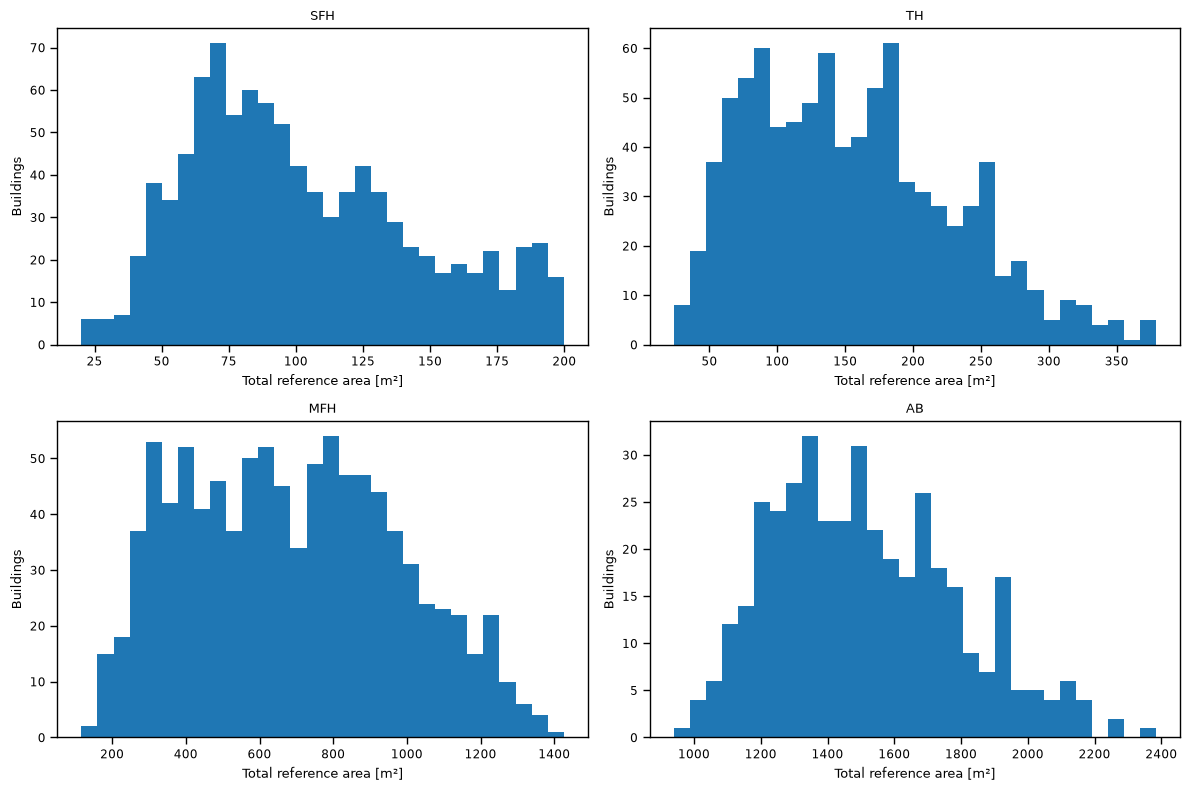

In [24]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_parquet("manifest.parquet")
b = df.drop_duplicates("building_id").copy()

fig, axes = plt.subplots(2, 2, figsize=(12, 8))

for ax, bt in zip(axes.flat, ["SFH", "TH", "MFH", "AB"]):
    x = b.loc[b["buildingType"] == bt, "a_ref"]

    ax.hist(x, bins=30)
    ax.set_title(bt)
    ax.set_xlabel("Total reference area [m²]")
    ax.set_ylabel("Buildings")

plt.tight_layout()
plt.show()

In [25]:
summary = (
    b.groupby("buildingType")
    .agg(
        n=("building_id", "size"),

        area_min=("a_ref", "min"),
        area_q05=("a_ref", lambda x: x.quantile(.05)),
        area_q25=("a_ref", lambda x: x.quantile(.25)),
        area_median=("a_ref", "median"),
        area_q75=("a_ref", lambda x: x.quantile(.75)),
        area_q95=("a_ref", lambda x: x.quantile(.95)),
        area_max=("a_ref", "max"),

        flats_min=("n_apartments", "min"),
        flats_mean=("n_apartments", "mean"),
        flats_max=("n_apartments", "max"),
    )
)

print(summary.round(1))

                n  area_min  area_q05  area_q25  area_median  area_q75  \
buildingType                                                             
AB            400     939.2    1117.4    1301.7       1480.8    1696.2   
MFH           960     116.6     263.4     444.0        673.8     899.8   
SFH           960      20.1      45.1      70.3         93.6     131.0   
TH            880      23.7      53.1      92.8        145.9     203.6   

              area_q95  area_max  flats_min  flats_mean  flats_max  
buildingType                                                        
AB              2014.0    2384.3         13        16.3         20  
MFH             1199.5    1425.8          3         7.4         12  
SFH              185.5     199.8          1         1.0          1  
TH               287.9     379.0          1         1.5          2  


In [26]:
b["area_per_apartment"] = (
    b["a_ref"] / b["n_apartments"]
)

print(
    b.groupby("buildingType")["area_per_apartment"]
    .describe(percentiles=[.05, .25, .5, .75, .95])
    .round(1)
)

              count   mean   std   min    5%   25%   50%    75%    95%    max
buildingType                                                                 
AB            400.0   92.8  10.1  72.2  77.5  85.2  92.5   99.2  110.3  126.3
MFH           960.0   93.2  16.9  38.9  65.6  81.6  92.9  104.1  120.4  161.6
SFH           960.0  102.8  42.5  20.1  45.1  70.3  93.6  131.0  185.5  199.8
TH            880.0  103.2  36.9  23.7  50.3  74.8  98.0  127.2  175.0  198.2
